# Offline Reinforcement Learning with D4RL PointMaze

### Portfolio Project

This corrected notebook uses the **D4RL PointMaze Medium benchmark** through the maintained **Minari + Gymnasium** ecosystem.

```text
D4RL benchmark dataset
        ↓
Minari dataset interface
        ↓
Gymnasium-Robotics PointMaze environment
        ↓
Complete dataset inspection
        ↓
(s, a, r, s') transition construction
        ↓
IQL from scratch with PyTorch
        ↓
IQL with d3rlpy
        ↓
CQL with d3rlpy
        ↓
Evaluation and comparison
```

> The original `hopper-medium-v2` / `env.get_dataset()` workflow belongs to the legacy D4RL/Gym stack. This notebook is rewritten for current Google Colab.

## What Is This Dataset About?

This project uses:

```text
D4RL/pointmaze/medium-v2
```

The data come from `PointMaze_Medium-v3`. A 2-DoF point mass moves through a closed maze using continuous forces in the Cartesian x and y directions.

The dataset contains **1,000,000 fixed transitions in 4,752 stored episodes**. A controller followed waypoint paths and action noise was added to create variation.

The reward is sparse:

- `1` when the point is within the goal region
- `0` otherwise

The offline RL algorithm never collects new transitions during training.

## What Is the Offline RL Agent Trying to Learn?

The goal is to learn a policy

$$
\pi(s) \rightarrow a
$$

from the fixed logged dataset.

The complete goal-conditioned observation contains:

- `observation`: 4 values
- `achieved_goal`: 2 values
- `desired_goal`: 2 values

After flattening:

$$
4+2+2=8
$$

The action is continuous with two components:

$$
a \in [-1,1]^2
$$

The learned policy should choose x/y forces that move the point toward the desired goal while staying within the support of the offline data.

## Dataset and Learning Problem at a Glance

| Property | Value |
|---|---|
| Benchmark family | D4RL |
| Dataset | `D4RL/pointmaze/medium-v2` |
| Environment | `PointMaze_Medium-v3` |
| Dataset interface | Minari |
| Task | Goal-conditioned maze navigation |
| Observation type | Dictionary |
| Flattened observation dimension | 8 |
| Action type | Continuous |
| Action dimension | 2 |
| Reward | Sparse |
| Primary method | Implicit Q-Learning (IQL) |
| Comparison method | Conservative Q-Learning (CQL) |

# Part I — Install and Import

## 1. Install Required Packages

Run this cell first in a fresh Google Colab runtime.

In [1]:
# ============================================================
# Install Required Libraries
# ============================================================
# We intentionally do NOT install the legacy `d4rl` or `gym`
# packages. D4RL PointMaze is accessed through Minari and
# Gymnasium-Robotics.

%pip install -q \
    minari \
    gymnasium \
    "gymnasium-robotics>=1.2.4" \
    mujoco \
    d3rlpy \
    numpy \
    pandas \
    matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.5/668.5 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into accoun

## 2. Import Libraries and Verify Versions

In [2]:
# ============================================================
# Import Libraries and Verify Versions
# ============================================================

import sys
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import minari
import gymnasium as gym
import gymnasium_robotics
import mujoco
import d3rlpy

gym.register_envs(gymnasium_robotics)

print("Python:             ", sys.version.split()[0])
print("Minari:             ", minari.__version__)
print("Gymnasium:          ", gym.__version__)
print("Gymnasium-Robotics: ", gymnasium_robotics.__version__)
print("MuJoCo:             ", mujoco.__version__)
print("d3rlpy:             ", d3rlpy.__version__)
print("NumPy:              ", np.__version__)
print("Pandas:             ", pd.__version__)

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Python:              3.13.15
Minari:              0.5.3
Gymnasium:           1.3.0
Gymnasium-Robotics:  1.4.2
MuJoCo:              3.12.0
d3rlpy:              2.8.0
NumPy:               2.1.3
Pandas:              2.2.3


## 3. Set a Reproducibility Seed

In [3]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seed:", SEED)

Seed: 42


# Part II — Load the D4RL Dataset and Environment

## 4. Load the D4RL PointMaze Dataset

In [4]:
# ============================================================
# Load D4RL PointMaze Medium Through Minari
# ============================================================

DATASET_ID = "D4RL/pointmaze/medium-v2"

dataset = minari.load_dataset(
    DATASET_ID,
    download=True,
)

print("Dataset loaded successfully.")
print("Dataset ID:", DATASET_ID)
print("Python type:", type(dataset))

namespace_metadata.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

metadata.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

metadata.json:   0%|          | 0.00/3.12k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

namespace_metadata.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset D4RL/pointmaze/medium-v2 downloaded to /root/.minari/datasets/D4RL/pointmaze/medium-v2
Dataset loaded successfully.
Dataset ID: D4RL/pointmaze/medium-v2
Python type: <class 'minari.dataset.minari_dataset.MinariDataset'>


## 5. Recover the Environment

Minari stores the environment specification with the dataset, so the associated Gymnasium environment can be recovered directly.

In [5]:
# ============================================================
# Recover the PointMaze Environment
# ============================================================

env = dataset.recover_environment()

print("Recovered environment:")
print(env)

print("\nEnvironment Python type:")
print(type(env))

print("\nEnvironment specification:")
print(env.spec)

Recovered environment:
<TimeLimit<OrderEnforcing<PassiveEnvChecker<PointMazeEnv<PointMaze_Medium-v3>>>>>

Environment Python type:
<class 'gymnasium.wrappers.common.TimeLimit'>

Environment specification:
EnvSpec(id='PointMaze_Medium-v3', entry_point='gymnasium_robotics.envs.maze.point_maze:PointMazeEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=1000000, order_enforce=True, disable_env_checker=False, kwargs={'maze_map': [[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 1, 0, 0, 0, 1, 1, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]], 'reward_type': 'sparse', 'continuing_task': True, 'reset_target': True}, namespace=None, name='PointMaze_Medium', version=3, additional_wrappers=(), vector_entry_point=None)


## 6. Inspect the Complete Observation Space

PointMaze uses a goal-conditioned `Dict` observation space rather than one flat `Box`.

In [6]:
# ============================================================
# Inspect the Complete Observation Space
# ============================================================

print("Complete observation space:")
print(env.observation_space)

print("\nObservation components:")

total_dimension = 0

for key, space in env.observation_space.spaces.items():
    dimension = int(np.prod(space.shape))
    total_dimension += dimension

    print(f"\n{key}:")
    print("  Space:", space)
    print("  Shape:", space.shape)
    print("  Dimension:", dimension)
    print("  Lower bounds:", space.low)
    print("  Upper bounds:", space.high)

print("\nTotal flattened observation dimension:")
print(total_dimension)

Complete observation space:
Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))

Observation components:

achieved_goal:
  Space: Box(-inf, inf, (2,), float64)
  Shape: (2,)
  Dimension: 2
  Lower bounds: [-inf -inf]
  Upper bounds: [inf inf]

desired_goal:
  Space: Box(-inf, inf, (2,), float64)
  Shape: (2,)
  Dimension: 2
  Lower bounds: [-inf -inf]
  Upper bounds: [inf inf]

observation:
  Space: Box(-inf, inf, (4,), float64)
  Shape: (4,)
  Dimension: 4
  Lower bounds: [-inf -inf -inf -inf]
  Upper bounds: [inf inf inf inf]

Total flattened observation dimension:
8


## 7. Human-Readable Observation Features

We flatten observations in the fixed order:

```text
observation → achieved_goal → desired_goal
```

In [7]:
# ============================================================
# Define Observation Feature Names
# ============================================================

OBSERVATION_KEYS = (
    "observation",
    "achieved_goal",
    "desired_goal",
)

STATE_FEATURE_NAMES = [
    "Ball x position",
    "Ball y position",
    "Ball x velocity",
    "Ball y velocity",
    "Achieved-goal x",
    "Achieved-goal y",
    "Desired-goal x",
    "Desired-goal y",
]

state_feature_table = pd.DataFrame(
    {
        "Index": range(len(STATE_FEATURE_NAMES)),
        "Feature": STATE_FEATURE_NAMES,
    }
)

state_feature_table

,Index,Feature
0,0,Ball x position
1,1,Ball y position
2,2,Ball x velocity
3,3,Ball y velocity
4,4,Achieved-goal x
5,5,Achieved-goal y
6,6,Desired-goal x
7,7,Desired-goal y


## 8. Inspect the Continuous Action Space

In [8]:
# ============================================================
# Inspect the Action Space
# ============================================================

print("Action space:")
print(env.action_space)

print("\nAction shape:")
print(env.action_space.shape)

print("\nAction dimension:")
print(env.action_space.shape[0])

print("\nAction lower bounds:")
print(env.action_space.low)

print("\nAction upper bounds:")
print(env.action_space.high)

Action space:
Box(-1.0, 1.0, (2,), float32)

Action shape:
(2,)

Action dimension:
2

Action lower bounds:
[-1. -1.]

Action upper bounds:
[1. 1.]


## 9. Human-Readable Action Components

In [9]:
# ============================================================
# Define Action Meanings
# ============================================================

ACTION_FEATURE_NAMES = [
    "Linear force in x direction",
    "Linear force in y direction",
]

action_feature_table = pd.DataFrame(
    {
        "Index": range(env.action_space.shape[0]),
        "Action Component": ACTION_FEATURE_NAMES,
        "Minimum": env.action_space.low,
        "Maximum": env.action_space.high,
    }
)

action_feature_table

,Index,Action Component,Minimum,Maximum
0,0,Linear force in x direction,-1.0,1.0
1,1,Linear force in y direction,-1.0,1.0


# Part III — Inspect the Stored Minari Episodes

## 10. Inspect the First Episode

For an episode containing \(T\) actions, Minari stores \(T+1\) observations so that each transition has both \(s_t\) and \(s_{t+1}\).

In [10]:
# ============================================================
# Inspect the First Episode
# ============================================================

first_episode = next(iter(dataset))

print("Episode Python type:")
print(type(first_episode))

print("\nEpisode ID:")
print(first_episode.id)

print("\nAction shape:")
print(first_episode.actions.shape)

print("\nReward shape:")
print(first_episode.rewards.shape)

print("\nTermination shape:")
print(first_episode.terminations.shape)

print("\nTruncation shape:")
print(first_episode.truncations.shape)

print("\nObservation components:")
for key, value in first_episode.observations.items():
    print(f"{key}: shape={value.shape}, dtype={value.dtype}")

Episode Python type:
<class 'minari.dataset.episode_data.EpisodeData'>

Episode ID:
0

Action shape:
(328, 2)

Reward shape:
(328,)

Termination shape:
(328,)

Truncation shape:
(328,)

Observation components:
achieved_goal: shape=(329, 2), dtype=float64
desired_goal: shape=(329, 2), dtype=float64
observation: shape=(329, 4), dtype=float64


## 11. Flatten the Goal-Conditioned Observation

A standard feed-forward neural network expects one numeric vector, so we define a single consistent conversion.

In [11]:
# ============================================================
# Flatten PointMaze Dictionary Observations
# ============================================================

def flatten_observation_dict(observation_dict):
    arrays = [
        np.asarray(observation_dict[key])
        for key in OBSERVATION_KEYS
    ]
    return np.concatenate(arrays, axis=-1)


first_episode_flat_observations = flatten_observation_dict(
    first_episode.observations
)

print("Flattened episode observation shape:")
print(first_episode_flat_observations.shape)

print("\nFirst flattened observation:")
print(first_episode_flat_observations[0])

Flattened episode observation shape:
(329, 8)

First flattened observation:
[-2.65781409 -1.66204705  0.          0.         -2.65781409 -1.66204705
 -2.72308949  2.36017994]


## 12. Print the First State Feature-by-Feature

In [12]:
# ============================================================
# Inspect One Flattened State
# ============================================================

first_state = first_episode_flat_observations[0]

first_state_table = pd.DataFrame(
    {
        "Index": range(len(first_state)),
        "Feature": STATE_FEATURE_NAMES,
        "Value": first_state,
    }
)

first_state_table

,Index,Feature,Value
0,0,Ball x position,-2.657814
1,1,Ball y position,-1.662047
2,2,Ball x velocity,0.000000
3,3,Ball y velocity,0.000000
4,4,Achieved-goal x,-2.657814
5,5,Achieved-goal y,-1.662047
6,6,Desired-goal x,-2.723089
7,7,Desired-goal y,2.360180


## 13. Print the First Action Component-by-Component

In [13]:
# ============================================================
# Inspect One Logged Action
# ============================================================

first_action = np.asarray(first_episode.actions[0])

first_action_table = pd.DataFrame(
    {
        "Index": range(len(first_action)),
        "Action Component": ACTION_FEATURE_NAMES,
        "Value": first_action,
    }
)

first_action_table

,Index,Action Component,Value
0,0,Linear force in x direction,1.0
1,1,Linear force in y direction,-1.0


# Part IV — Convert Minari Episodes to Standard Offline-RL Transitions

## 14. Build Aligned Transition Arrays

For each stored episode we construct:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1})
$$

plus termination and truncation information.

This replaces the legacy `env.get_dataset()` and `d4rl.qlearning_dataset(env)` workflow.

In [14]:
# ============================================================
# Convert Minari Episodes into Aligned Transition Arrays
# ============================================================

observations_list = []
next_observations_list = []
actions_list = []
rewards_list = []
terminations_list = []
truncations_list = []

episode_lengths = []
episode_returns = []

for episode in dataset:

    episode_observations = flatten_observation_dict(
        episode.observations
    ).astype(np.float32)

    episode_actions = np.asarray(
        episode.actions,
        dtype=np.float32,
    )

    episode_rewards = np.asarray(
        episode.rewards,
        dtype=np.float32,
    ).reshape(-1)

    episode_terminations = np.asarray(
        episode.terminations,
        dtype=bool,
    ).reshape(-1)

    episode_truncations = np.asarray(
        episode.truncations,
        dtype=bool,
    ).reshape(-1)

    num_steps = len(episode_actions)

    assert len(episode_observations) == num_steps + 1
    assert len(episode_rewards) == num_steps
    assert len(episode_terminations) == num_steps
    assert len(episode_truncations) == num_steps

    observations_list.append(episode_observations[:-1])
    next_observations_list.append(episode_observations[1:])
    actions_list.append(episode_actions)
    rewards_list.append(episode_rewards)
    terminations_list.append(episode_terminations)
    truncations_list.append(episode_truncations)

    episode_lengths.append(num_steps)
    episode_returns.append(float(episode_rewards.sum()))


raw_dataset = {
    "observations": np.concatenate(observations_list, axis=0),
    "actions": np.concatenate(actions_list, axis=0),
    "rewards": np.concatenate(rewards_list, axis=0),
    "next_observations": np.concatenate(next_observations_list, axis=0),
    "terminations": np.concatenate(terminations_list, axis=0),
    "truncations": np.concatenate(truncations_list, axis=0),
}

print("Transition arrays created successfully.")

Transition arrays created successfully.


## 15. Inspect Every Transition Array

For every field, print the Python type, shape, dtype, and a small preview.

In [15]:
# ============================================================
# Inspect the Complete Transition Dataset
# ============================================================

print("=" * 80)
print("D4RL POINTMAZE TRANSITION DATASET")
print("=" * 80)

for key, value in raw_dataset.items():
    print(f"\nKEY: {key}")
    print("Python type:", type(value))
    print("Shape:", value.shape)
    print("Dtype:", value.dtype)
    print("Preview:")
    print(value[:3])

D4RL POINTMAZE TRANSITION DATASET

KEY: observations
Python type: <class 'numpy.ndarray'>
Shape: (1000000, 8)
Dtype: float32
Preview:
[[-2.657814   -1.662047    0.          0.         -2.657814   -1.662047
  -2.7230895   2.36018   ]
 [-2.6554325  -1.6644287   0.23816384 -0.23816384 -2.6554325  -1.6644287
  -2.7230895   2.36018   ]
 [-2.6506748  -1.6691862   0.47576046 -0.47576046 -2.6506748  -1.6691862
  -2.7230895   2.36018   ]]

KEY: actions
Python type: <class 'numpy.ndarray'>
Shape: (1000000, 2)
Dtype: float32
Preview:
[[ 1.         -1.        ]
 [ 1.         -1.        ]
 [ 0.74168795 -1.        ]]

KEY: rewards
Python type: <class 'numpy.ndarray'>
Shape: (1000000,)
Dtype: float32
Preview:
[0. 0. 0.]

KEY: next_observations
Python type: <class 'numpy.ndarray'>
Shape: (1000000, 8)
Dtype: float32
Preview:
[[-2.6554325  -1.6644287   0.23816384 -0.23816384 -2.6554325  -1.6644287
  -2.7230895   2.36018   ]
 [-2.6506748  -1.6691862   0.47576046 -0.47576046 -2.6506748  -1.6691862
  -2.72

## 16. Verify Dataset Size and Dimensions

In [16]:
# ============================================================
# Verify Core Dataset Dimensions
# ============================================================

num_transitions = len(raw_dataset["rewards"])
state_dim = raw_dataset["observations"].shape[1]
action_dim = raw_dataset["actions"].shape[1]

print("Number of transitions:", num_transitions)
print("Number of stored episodes:", len(episode_lengths))
print("Flattened state dimension:", state_dim)
print("Action dimension:", action_dim)

assert raw_dataset["observations"].shape == (
    num_transitions,
    len(STATE_FEATURE_NAMES),
)

assert raw_dataset["next_observations"].shape == (
    num_transitions,
    len(STATE_FEATURE_NAMES),
)

assert raw_dataset["actions"].shape == (
    num_transitions,
    len(ACTION_FEATURE_NAMES),
)

assert raw_dataset["rewards"].shape == (
    num_transitions,
)

print("\nAll shape checks passed.")

Number of transitions: 1000000
Number of stored episodes: 4752
Flattened state dimension: 8
Action dimension: 2

All shape checks passed.


## 17. Print One Complete Offline-RL Transition

This directly displays:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1})
$$

In [17]:
# ============================================================
# Print One Complete Transition
# ============================================================

transition_index = 0

print("=" * 80)
print("ONE COMPLETE OFFLINE-RL TRANSITION")
print("=" * 80)

print("\nSTATE s_t:")
print(raw_dataset["observations"][transition_index])

print("\nACTION a_t:")
print(raw_dataset["actions"][transition_index])

print("\nREWARD r_t:")
print(raw_dataset["rewards"][transition_index])

print("\nNEXT STATE s_(t+1):")
print(raw_dataset["next_observations"][transition_index])

print("\nTERMINATED:")
print(raw_dataset["terminations"][transition_index])

print("\nTRUNCATED:")
print(raw_dataset["truncations"][transition_index])

ONE COMPLETE OFFLINE-RL TRANSITION

STATE s_t:
[-2.657814  -1.662047   0.         0.        -2.657814  -1.662047
 -2.7230895  2.36018  ]

ACTION a_t:
[ 1. -1.]

REWARD r_t:
0.0

NEXT STATE s_(t+1):
[-2.6554325  -1.6644287   0.23816384 -0.23816384 -2.6554325  -1.6644287
 -2.7230895   2.36018   ]

TERMINATED:
False

TRUNCATED:
False


## 18. Build a Compact Transition Preview Table

In [18]:
# ============================================================
# Preview the First 10 Transitions
# ============================================================

preview_rows = []

for i in range(10):
    preview_rows.append(
        {
            "Index": i,
            "State x": raw_dataset["observations"][i, 0],
            "State y": raw_dataset["observations"][i, 1],
            "Goal x": raw_dataset["observations"][i, 6],
            "Goal y": raw_dataset["observations"][i, 7],
            "Action x": raw_dataset["actions"][i, 0],
            "Action y": raw_dataset["actions"][i, 1],
            "Reward": raw_dataset["rewards"][i],
            "Terminated": raw_dataset["terminations"][i],
            "Truncated": raw_dataset["truncations"][i],
        }
    )

transition_preview = pd.DataFrame(preview_rows)
transition_preview

,Index,State x,State y,Goal x,Goal y,Action x,Action y,Reward,Terminated,Truncated
0,0,-2.657814,-1.662047,-2.723089,2.36018,1.000000,-1.0,0.0,False,False
1,1,-2.655432,-1.664429,-2.723089,2.36018,1.000000,-1.0,0.0,False,False
2,2,-2.650675,-1.669186,-2.723089,2.36018,0.741688,-1.0,0.0,False,False
3,3,-2.644162,-1.676314,-2.723089,2.36018,-0.422989,-1.0,0.0,False,False
4,4,-2.638672,-1.685807,-2.723089,2.36018,1.000000,-1.0,0.0,False,False
5,5,-2.630814,-1.697658,-2.723089,2.36018,0.182862,-1.0,0.0,False,False
6,6,-2.622539,-1.711863,-2.723089,2.36018,1.000000,-1.0,0.0,False,False
7,7,-2.611902,-1.728416,-2.723089,2.36018,-0.166681,-1.0,0.0,False,False
8,8,-2.601687,-1.747311,-2.723089,2.36018,1.000000,-1.0,0.0,False,False
9,9,-2.589115,-1.768543,-2.723089,2.36018,0.135968,-1.0,0.0,False,False


# Part V — Episode Boundaries and Dataset Statistics

## 19. Terminations vs. Truncations

Gymnasium distinguishes true MDP termination from external truncation. The PointMaze dataset uses a continuing-task configuration, but Minari preserves both signals.

In [19]:
# ============================================================
# Inspect Termination and Truncation Flags
# ============================================================

terminal_flags = raw_dataset["terminations"].astype(bool)
truncation_flags = raw_dataset["truncations"].astype(bool)

overlap_flags = np.logical_and(
    terminal_flags,
    truncation_flags,
)

print("Terminal transitions:", int(terminal_flags.sum()))
print("Truncated transitions:", int(truncation_flags.sum()))
print("Terminal AND truncated:", int(overlap_flags.sum()))

Terminal transitions: 0
Truncated transitions: 4752
Terminal AND truncated: 0


## 20. Episode-Level Statistics

In [20]:
# ============================================================
# Episode-Level Descriptive Statistics
# ============================================================

episode_statistics = pd.DataFrame(
    {
        "Episode Length": episode_lengths,
        "Episode Return": episode_returns,
    }
)

episode_statistics.describe()

,Episode Length,Episode Return
count,4752.000000,4752.000000
mean,210.437710,0.998948
std,125.741994,0.032424
min,1.000000,0.000000
25%,102.000000,1.000000
50%,205.000000,1.000000
75%,309.000000,1.000000
max,504.000000,1.000000


## 21. Plot Episode Length Distribution

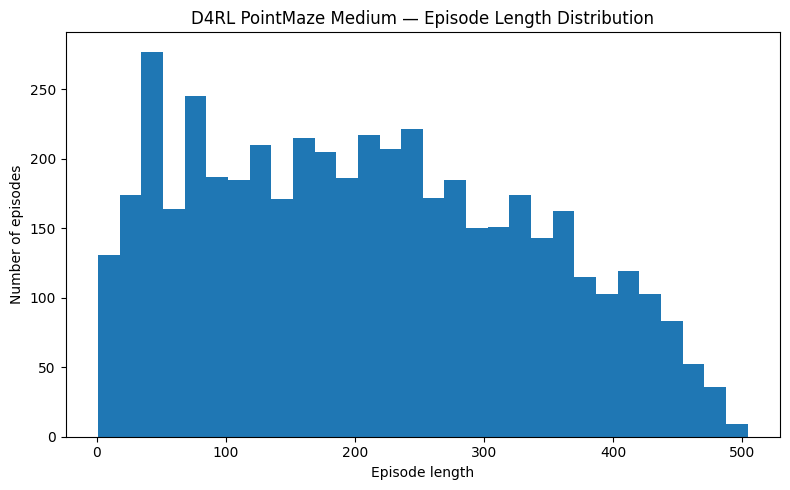

In [21]:
# ============================================================
# Plot Episode Length Distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(episode_lengths, bins=30)
plt.xlabel("Episode length")
plt.ylabel("Number of episodes")
plt.title("D4RL PointMaze Medium — Episode Length Distribution")
plt.tight_layout()
plt.show()

## 22. Plot Episode Return Distribution

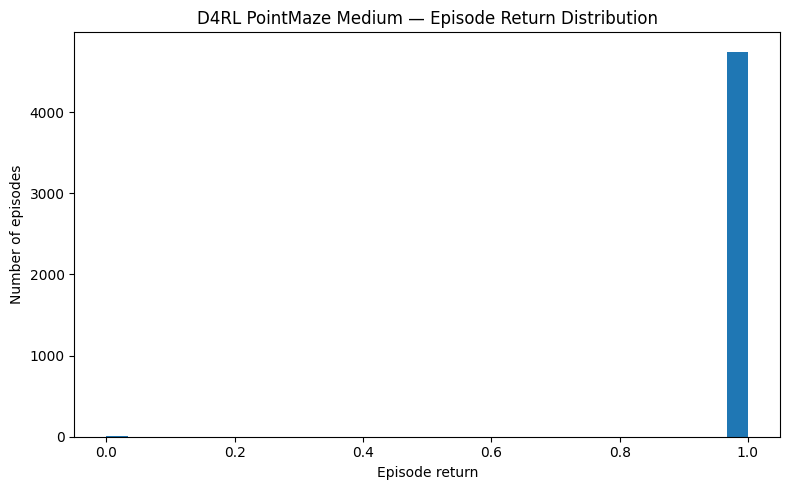

In [22]:
# ============================================================
# Plot Episode Return Distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(episode_returns, bins=30)
plt.xlabel("Episode return")
plt.ylabel("Number of episodes")
plt.title("D4RL PointMaze Medium — Episode Return Distribution")
plt.tight_layout()
plt.show()

## 23. Reward Statistics

In [23]:
# ============================================================
# Summarize Transition Rewards
# ============================================================

reward_series = pd.Series(
    raw_dataset["rewards"],
    name="reward",
)

print(reward_series.describe())

print("\nUnique reward values:")
print(np.unique(raw_dataset["rewards"]))

print("\nRewarding transitions:")
print(int(np.sum(raw_dataset["rewards"] > 0)))

count    1000000.000000
mean           0.004747
std            0.068591
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max            1.000000
Name: reward, dtype: float64

Unique reward values:
[0. 1.]

Rewarding transitions:
4747


## 24. Plot Transition Reward Distribution

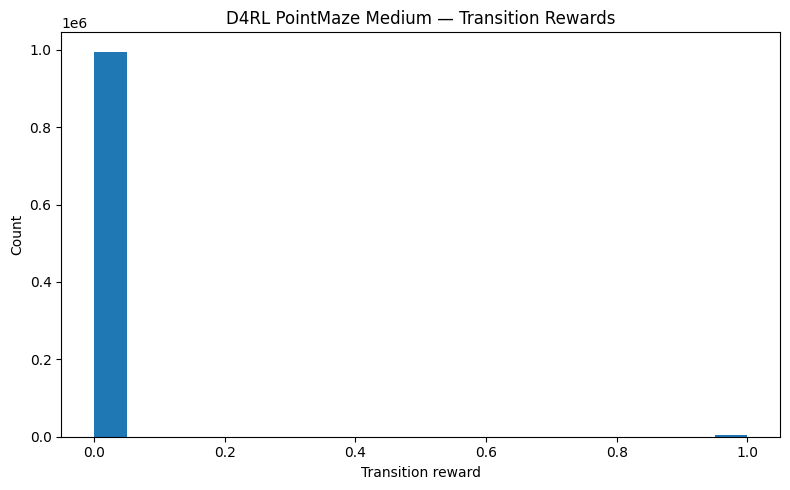

In [24]:
# ============================================================
# Plot Transition Reward Distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(raw_dataset["rewards"], bins=20)
plt.xlabel("Transition reward")
plt.ylabel("Count")
plt.title("D4RL PointMaze Medium — Transition Rewards")
plt.tight_layout()
plt.show()

## 25. State Feature Statistics

In [25]:
# ============================================================
# State Feature Statistics
# ============================================================

state_dataframe = pd.DataFrame(
    raw_dataset["observations"],
    columns=STATE_FEATURE_NAMES,
)

state_dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
Ball x position,1000000.0,-0.493096,1.543756,-2.843573,-1.693599,-0.565491,0.481679,2.824203
Ball y position,1000000.0,-0.731056,1.395273,-2.863502,-1.780351,-0.684503,0.347284,2.825196
Ball x velocity,1000000.0,0.000265,2.451991,-5.226255,-1.110923,-0.004256,1.185946,5.226255
Ball y velocity,1000000.0,-0.000183,2.695283,-5.226255,-1.703795,-0.000205,1.749793,5.226255
Achieved-goal x,1000000.0,-0.493096,1.543756,-2.843573,-1.693599,-0.565491,0.481679,2.824203
Achieved-goal y,1000000.0,-0.731056,1.395273,-2.863502,-1.780351,-0.684503,0.347284,2.825196
Desired-goal x,1000000.0,-0.074566,1.853103,-2.748241,-1.639976,-0.323915,1.598355,2.749115
Desired-goal y,1000000.0,0.023601,1.779734,-2.749878,-1.548134,-0.270531,1.580879,2.748718


## 26. Action Component Statistics

In [26]:
# ============================================================
# Action Component Statistics
# ============================================================

action_dataframe = pd.DataFrame(
    raw_dataset["actions"],
    columns=ACTION_FEATURE_NAMES,
)

action_dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
Linear force in x direction,1000000.0,-0.004472,0.812693,-1.0,-1.0,-0.007413,1.0,1.0
Linear force in y direction,1000000.0,-0.003925,0.840215,-1.0,-1.0,-0.006095,1.0,1.0


## 27. Plot the Two Action Distributions

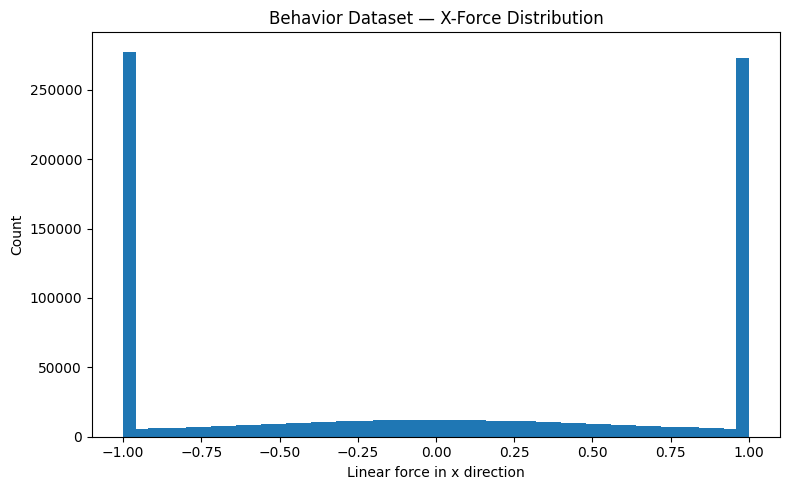

In [27]:
# ============================================================
# Plot X-Force Distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(raw_dataset["actions"][:, 0], bins=50)
plt.xlabel("Linear force in x direction")
plt.ylabel("Count")
plt.title("Behavior Dataset — X-Force Distribution")
plt.tight_layout()
plt.show()

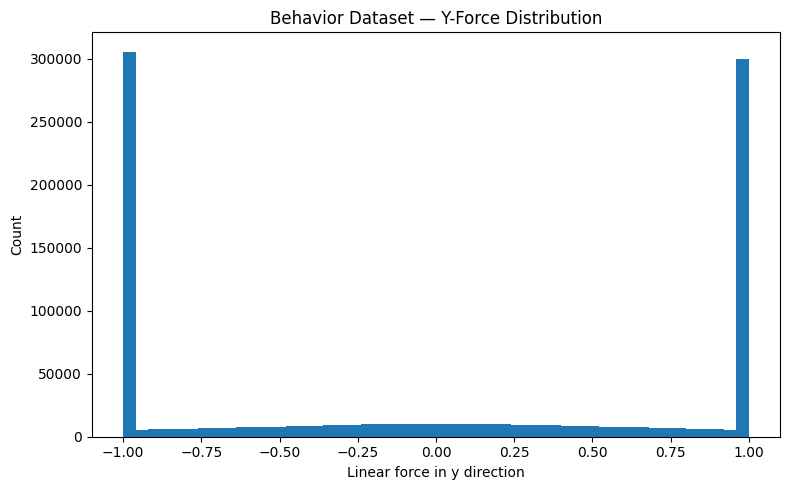

In [28]:
# ============================================================
# Plot Y-Force Distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(raw_dataset["actions"][:, 1], bins=50)
plt.xlabel("Linear force in y direction")
plt.ylabel("Count")
plt.title("Behavior Dataset — Y-Force Distribution")
plt.tight_layout()
plt.show()

## 28. Final Dataset Summary

In [29]:
# ============================================================
# Portfolio-Friendly Dataset Summary
# ============================================================

dataset_summary = pd.DataFrame(
    {
        "Property": [
            "Benchmark family",
            "Dataset ID",
            "Environment",
            "Dataset interface",
            "Transitions",
            "Episodes",
            "Observation type",
            "Flattened observation dimension",
            "Action type",
            "Action dimension",
            "Reward type",
        ],
        "Value": [
            "D4RL",
            DATASET_ID,
            env.spec.id,
            "Minari",
            num_transitions,
            len(episode_lengths),
            "Goal-conditioned Dict",
            state_dim,
            "Continuous Box",
            action_dim,
            "Sparse",
        ],
    }
)

dataset_summary

,Property,Value
0,Benchmark family,D4RL
1,Dataset ID,D4RL/pointmaze/medium-v2
2,Environment,PointMaze_Medium-v3
3,Dataset interface,Minari
4,Transitions,1000000
5,Episodes,4752
6,Observation type,Goal-conditioned Dict
7,Flattened observation dimension,8
8,Action type,Continuous Box
9,Action dimension,2


# Part VI — Prepare the Q-Learning Dataset

## 29. Create the Standard Training Representation

For value-learning we use explicit arrays:

```text
observations
actions
rewards
next_observations
terminals
timeouts
```

True terminal states stop Bellman bootstrapping. Truncations are preserved separately.

In [30]:
# ============================================================
# Q-Learning-Style Dictionary
# ============================================================

q_dataset = {
    "observations": raw_dataset["observations"].astype(np.float32),
    "actions": raw_dataset["actions"].astype(np.float32),
    "rewards": raw_dataset["rewards"].astype(np.float32),
    "next_observations": raw_dataset["next_observations"].astype(np.float32),
    "terminals": raw_dataset["terminations"].astype(np.float32),
    "timeouts": raw_dataset["truncations"].astype(np.float32),
}

for key, value in q_dataset.items():
    print(f"{key:18s} shape={value.shape}, dtype={value.dtype}")

observations       shape=(1000000, 8), dtype=float32
actions            shape=(1000000, 2), dtype=float32
rewards            shape=(1000000,), dtype=float32
next_observations  shape=(1000000, 8), dtype=float32
terminals          shape=(1000000,), dtype=float32
timeouts           shape=(1000000,), dtype=float32


## 30. Validate Terminal/Timeout Compatibility for d3rlpy

`d3rlpy.MDPDataset` requires a transition not to be both terminal and timeout. If overlap exists, the d3rlpy conversion preserves the true terminal flag and removes only the overlapping timeout flag.

In [31]:
# ============================================================
# Make Terminal and Timeout Mutually Exclusive for d3rlpy
# ============================================================

d3_terminals = raw_dataset["terminations"].astype(bool).copy()
d3_timeouts = raw_dataset["truncations"].astype(bool).copy()

overlap_before = np.logical_and(
    d3_terminals,
    d3_timeouts,
)

print("Overlap before conversion:", int(overlap_before.sum()))

d3_timeouts = np.logical_and(
    d3_timeouts,
    np.logical_not(d3_terminals),
)

overlap_after = np.logical_and(
    d3_terminals,
    d3_timeouts,
)

print("Overlap after conversion:", int(overlap_after.sum()))

Overlap before conversion: 0
Overlap after conversion: 0


# Part VII — Method 1: Implicit Q-Learning (IQL)

## 31. Why IQL?

IQL avoids explicitly maximizing Q-values over arbitrary unseen actions. It learns:

1. twin critics \(Q_1(s,a)\), \(Q_2(s,a)\)
2. a state-value function \(V(s)\)
3. a policy \(\pi(a|s)\)

The value function uses expectile regression, and policy extraction uses advantage-weighted behavior cloning.

## 32. IQL Pros and Cons

### Pros
- designed for offline RL
- avoids explicit maximization over unseen actions
- natural for continuous action spaces
- strong fit for D4RL-style datasets

### Cons
- sensitive to expectile and temperature settings
- still limited by dataset coverage
- sparse rewards can make learning difficult
- deep neural training requires compute

## 33. What “From Scratch” Means Here

The IQL update rules are written manually. PyTorch is used only for tensors, neural networks, and automatic differentiation. No ready-made IQL algorithm is called in this section.

## 34. Import PyTorch and Select Device

In [32]:
# ============================================================
# Import PyTorch
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
Device: cuda


## 35. Prepare Training Arrays

In [33]:
# ============================================================
# Prepare Offline Training Arrays
# ============================================================

observations = q_dataset["observations"]
actions = q_dataset["actions"]
rewards = q_dataset["rewards"].reshape(-1, 1)
next_observations = q_dataset["next_observations"]
terminals = q_dataset["terminals"].reshape(-1, 1)

STATE_DIM = observations.shape[1]
ACTION_DIM = actions.shape[1]

print("Observations:", observations.shape)
print("Actions:", actions.shape)
print("Rewards:", rewards.shape)
print("Next observations:", next_observations.shape)
print("Terminals:", terminals.shape)
print("STATE_DIM:", STATE_DIM)
print("ACTION_DIM:", ACTION_DIM)

Observations: (1000000, 8)
Actions: (1000000, 2)
Rewards: (1000000, 1)
Next observations: (1000000, 8)
Terminals: (1000000, 1)
STATE_DIM: 8
ACTION_DIM: 2


## 36. Normalize Observations

Normalization statistics are computed only from the fixed offline training observations.

In [34]:
# ============================================================
# Standardize State Features
# ============================================================

state_mean = observations.mean(
    axis=0,
    keepdims=True,
)

state_std = observations.std(
    axis=0,
    keepdims=True,
)

state_std = np.where(
    state_std < 1e-6,
    1.0,
    state_std,
)

normalized_observations = (
    observations - state_mean
) / state_std

normalized_next_observations = (
    next_observations - state_mean
) / state_std

print("State mean shape:", state_mean.shape)
print("State std shape:", state_std.shape)
print("Normalized observations:", normalized_observations.shape)

State mean shape: (1, 8)
State std shape: (1, 8)
Normalized observations: (1000000, 8)


## 37. Define the Q-Network

In [35]:
# ============================================================
# Continuous-Action Q-Network
# ============================================================

class QNetwork(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=256,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state, action):
        x = torch.cat(
            [state, action],
            dim=-1,
        )
        return self.network(x)

## 38. Define the State-Value Network

In [36]:
# ============================================================
# IQL State-Value Network
# ============================================================

class ValueNetwork(nn.Module):

    def __init__(
        self,
        state_dim,
        hidden_dim=256,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state):
        return self.network(state)

## 39. Define a Tanh-Gaussian Policy

The `tanh` output matches the PointMaze action bounds \([-1,1]\).

In [37]:
# ============================================================
# Tanh-Gaussian Policy
# ============================================================

LOG_STD_MIN = -5.0
LOG_STD_MAX = 2.0


class GaussianPolicy(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=256,
    ):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mean_layer = nn.Linear(hidden_dim, action_dim)
        self.log_std_layer = nn.Linear(hidden_dim, action_dim)

    def distribution_parameters(self, state):

        hidden = self.backbone(state)

        mean = self.mean_layer(hidden)

        log_std = self.log_std_layer(hidden)
        log_std = torch.clamp(
            log_std,
            LOG_STD_MIN,
            LOG_STD_MAX,
        )

        return mean, log_std

    def log_prob(self, state, bounded_action):

        clipped_action = torch.clamp(
            bounded_action,
            -0.999999,
            0.999999,
        )

        raw_action = torch.atanh(clipped_action)

        mean, log_std = self.distribution_parameters(state)
        std = log_std.exp()

        normal = torch.distributions.Normal(mean, std)

        raw_log_prob = normal.log_prob(
            raw_action
        ).sum(
            dim=-1,
            keepdim=True,
        )

        correction = torch.log(
            1.0 - clipped_action.pow(2) + 1e-6
        ).sum(
            dim=-1,
            keepdim=True,
        )

        return raw_log_prob - correction

    def deterministic_action(self, state):

        mean, _ = self.distribution_parameters(state)

        return torch.tanh(mean)

## 40. Define the Expectile Loss

In [38]:
# ============================================================
# IQL Expectile Loss
# ============================================================

def expectile_loss(
    difference,
    expectile,
):
    weight = torch.where(
        difference > 0,
        expectile,
        1.0 - expectile,
    )

    return (
        weight
        * difference.pow(2)
    ).mean()

## 41. Define Manual IQL Hyperparameters

The training budget is moderate so the notebook remains practical in Colab. Increase it for a serious benchmark experiment.

In [39]:
# ============================================================
# Manual IQL Hyperparameters
# ============================================================

GAMMA = 0.99
EXPECTILE = 0.7
ADVANTAGE_TEMPERATURE = 3.0
MAX_ADVANTAGE_WEIGHT = 100.0

BATCH_SIZE = 256
LEARNING_RATE = 3e-4
TAU = 0.005

MANUAL_IQL_STEPS = 20_000
LOG_INTERVAL = 500

print("Manual IQL training steps:", MANUAL_IQL_STEPS)

Manual IQL training steps: 20000


## 42. Create Networks and Optimizers

In [40]:
# ============================================================
# Create Manual IQL Models and Optimizers
# ============================================================

q1 = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
q2 = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)

target_q1 = copy.deepcopy(q1).to(DEVICE)
target_q2 = copy.deepcopy(q2).to(DEVICE)

value_network = ValueNetwork(STATE_DIM).to(DEVICE)
policy = GaussianPolicy(STATE_DIM, ACTION_DIM).to(DEVICE)

q_optimizer = torch.optim.Adam(
    list(q1.parameters()) + list(q2.parameters()),
    lr=LEARNING_RATE,
)

value_optimizer = torch.optim.Adam(
    value_network.parameters(),
    lr=LEARNING_RATE,
)

policy_optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=LEARNING_RATE,
)

print("Networks and optimizers created.")

Networks and optimizers created.


## 43. Define Random Offline Minibatch Sampling

The sampler uses only the fixed D4RL dataset.

In [41]:
# ============================================================
# Offline Minibatch Sampler
# ============================================================

def sample_offline_batch(batch_size):

    indices = np.random.randint(
        0,
        len(normalized_observations),
        size=batch_size,
    )

    batch_states = torch.as_tensor(
        normalized_observations[indices],
        dtype=torch.float32,
        device=DEVICE,
    )

    batch_actions = torch.as_tensor(
        actions[indices],
        dtype=torch.float32,
        device=DEVICE,
    )

    batch_rewards = torch.as_tensor(
        rewards[indices],
        dtype=torch.float32,
        device=DEVICE,
    )

    batch_next_states = torch.as_tensor(
        normalized_next_observations[indices],
        dtype=torch.float32,
        device=DEVICE,
    )

    batch_terminals = torch.as_tensor(
        terminals[indices],
        dtype=torch.float32,
        device=DEVICE,
    )

    return (
        batch_states,
        batch_actions,
        batch_rewards,
        batch_next_states,
        batch_terminals,
    )

## 44. Define the Soft Target-Network Update

$$
\theta_{target}
\leftarrow
(1-\tau)\theta_{target}+\tau\theta
$$

In [42]:
# ============================================================
# Soft Target-Network Update
# ============================================================

def soft_update(
    target_network,
    source_network,
    tau,
):

    with torch.no_grad():

        for target_parameter, source_parameter in zip(
            target_network.parameters(),
            source_network.parameters(),
        ):
            target_parameter.data.mul_(1.0 - tau)
            target_parameter.data.add_(
                tau * source_parameter.data
            )

## 45. Manual IQL Update Logic

### Value update

$$
Q_{\min}(s,a)=\min(Q_1(s,a),Q_2(s,a))
$$

The value network is fit with expectile regression.

### Critic update

$$
y=r+\gamma(1-d)V(s')
$$

### Policy update

$$
A(s,a)=Q_{\min}(s,a)-V(s)
$$

and logged actions are weighted by:

$$
w=\min(\exp(\beta A), w_{\max})
$$

## 46. Train IQL from Scratch

In [43]:
# ============================================================
# Train Manual IQL Entirely from the Fixed Dataset
# ============================================================

manual_iql_history = []

for training_step in range(
    1,
    MANUAL_IQL_STEPS + 1,
):

    (
        batch_states,
        batch_actions,
        batch_rewards,
        batch_next_states,
        batch_terminals,
    ) = sample_offline_batch(BATCH_SIZE)

    # --------------------------------------------------------
    # 1. VALUE UPDATE
    # --------------------------------------------------------

    with torch.no_grad():

        target_q_value = torch.minimum(
            target_q1(batch_states, batch_actions),
            target_q2(batch_states, batch_actions),
        )

    predicted_value = value_network(batch_states)

    value_difference = (
        target_q_value - predicted_value
    )

    value_loss = expectile_loss(
        value_difference,
        EXPECTILE,
    )

    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

    # --------------------------------------------------------
    # 2. CRITIC UPDATE
    # --------------------------------------------------------

    with torch.no_grad():

        next_value = value_network(
            batch_next_states
        )

        bellman_target = (
            batch_rewards
            + GAMMA
            * (1.0 - batch_terminals)
            * next_value
        )

    q1_prediction = q1(
        batch_states,
        batch_actions,
    )

    q2_prediction = q2(
        batch_states,
        batch_actions,
    )

    q_loss = (
        F.mse_loss(
            q1_prediction,
            bellman_target,
        )
        + F.mse_loss(
            q2_prediction,
            bellman_target,
        )
    )

    q_optimizer.zero_grad()
    q_loss.backward()
    q_optimizer.step()

    # --------------------------------------------------------
    # 3. POLICY UPDATE
    # --------------------------------------------------------

    with torch.no_grad():

        q_min = torch.minimum(
            q1(batch_states, batch_actions),
            q2(batch_states, batch_actions),
        )

        state_value = value_network(
            batch_states
        )

        advantage = q_min - state_value

        advantage_weight = torch.exp(
            ADVANTAGE_TEMPERATURE
            * advantage
        ).clamp(
            max=MAX_ADVANTAGE_WEIGHT
        )

    log_probability = policy.log_prob(
        batch_states,
        batch_actions,
    )

    policy_loss = -(
        advantage_weight
        * log_probability
    ).mean()

    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()

    # --------------------------------------------------------
    # 4. TARGET UPDATES
    # --------------------------------------------------------

    soft_update(target_q1, q1, TAU)
    soft_update(target_q2, q2, TAU)

    # --------------------------------------------------------
    # 5. LOGGING
    # --------------------------------------------------------

    if (
        training_step == 1
        or training_step % LOG_INTERVAL == 0
    ):
        row = {
            "Step": training_step,
            "Value Loss": float(
                value_loss.detach().cpu()
            ),
            "Q Loss": float(
                q_loss.detach().cpu()
            ),
            "Policy Loss": float(
                policy_loss.detach().cpu()
            ),
        }

        manual_iql_history.append(row)
        print(row)

{'Step': 1, 'Value Loss': 0.0057750483974814415, 'Q Loss': 0.03302432596683502, 'Policy Loss': 16.199718475341797}
{'Step': 500, 'Value Loss': 5.0910821300931275e-05, 'Q Loss': 0.0012417788384482265, 'Policy Loss': -9.238382339477539}
{'Step': 1000, 'Value Loss': 5.256021540844813e-05, 'Q Loss': 0.0008577753324061632, 'Policy Loss': -8.614446640014648}
{'Step': 1500, 'Value Loss': 6.23423547949642e-05, 'Q Loss': 0.008007191121578217, 'Policy Loss': -7.9198832511901855}
{'Step': 2000, 'Value Loss': 7.277884287759662e-05, 'Q Loss': 0.0006768965977244079, 'Policy Loss': -8.443099975585938}
{'Step': 2500, 'Value Loss': 9.954783308785409e-05, 'Q Loss': 0.009236238896846771, 'Policy Loss': -9.06602668762207}
{'Step': 3000, 'Value Loss': 0.0001513469178462401, 'Q Loss': 0.004489650949835777, 'Policy Loss': -7.868631839752197}
{'Step': 3500, 'Value Loss': 0.00023283973860088736, 'Q Loss': 0.02777193859219551, 'Policy Loss': -9.121786117553711}
{'Step': 4000, 'Value Loss': 0.0001444155641365796

## 47. Plot Manual IQL Training Losses

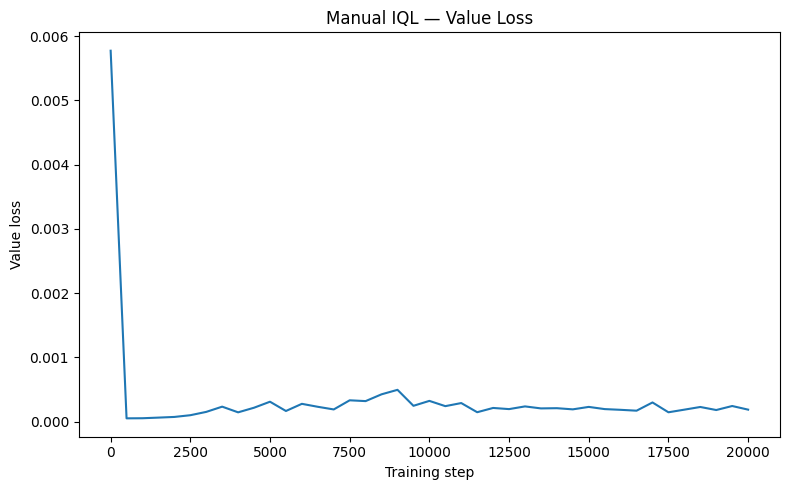

In [44]:
# ============================================================
# Plot Manual IQL Value Loss
# ============================================================

manual_iql_history_df = pd.DataFrame(
    manual_iql_history
)

plt.figure(figsize=(8, 5))
plt.plot(
    manual_iql_history_df["Step"],
    manual_iql_history_df["Value Loss"],
)
plt.xlabel("Training step")
plt.ylabel("Value loss")
plt.title("Manual IQL — Value Loss")
plt.tight_layout()
plt.show()

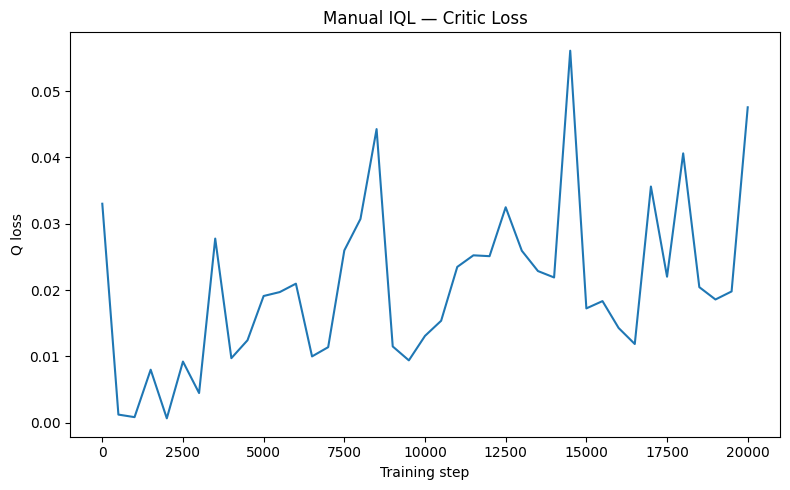

In [45]:
# ============================================================
# Plot Manual IQL Q Loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    manual_iql_history_df["Step"],
    manual_iql_history_df["Q Loss"],
)
plt.xlabel("Training step")
plt.ylabel("Q loss")
plt.title("Manual IQL — Critic Loss")
plt.tight_layout()
plt.show()

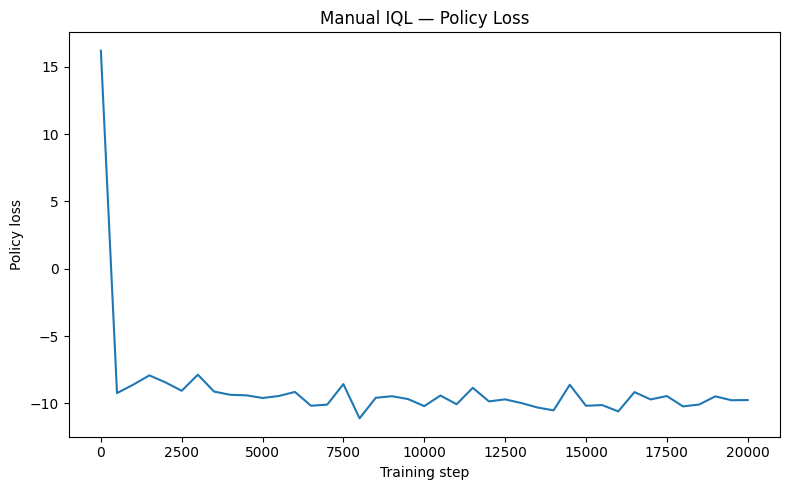

In [46]:
# ============================================================
# Plot Manual IQL Policy Loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    manual_iql_history_df["Step"],
    manual_iql_history_df["Policy Loss"],
)
plt.xlabel("Training step")
plt.ylabel("Policy loss")
plt.title("Manual IQL — Policy Loss")
plt.tight_layout()
plt.show()

# Part VIII — Evaluate the Manual IQL Policy

## 48. Evaluation Protocol

Training is fully offline. Evaluation is performed only after training by running the learned policy in the recovered simulator.

The dataset environment has a very large maximum episode length, so this notebook uses a fixed 500-step evaluation horizon for every policy.

In [47]:
# ============================================================
# Flatten One Environment Observation
# ============================================================

def flatten_single_environment_observation(
    observation_dict
):
    return flatten_observation_dict(
        observation_dict
    ).astype(np.float32)

## 49. Define Manual IQL Action Prediction

In [48]:
# ============================================================
# Deterministic Manual IQL Action Prediction
# ============================================================

def predict_manual_iql_action(
    observation_dict
):

    flat_observation = (
        flatten_single_environment_observation(
            observation_dict
        )
    )

    normalized_state = (
        flat_observation
        - state_mean[0]
    ) / state_std[0]

    state_tensor = torch.as_tensor(
        normalized_state,
        dtype=torch.float32,
        device=DEVICE,
    ).unsqueeze(0)

    with torch.no_grad():

        action = policy.deterministic_action(
            state_tensor
        )[0].cpu().numpy()

    return np.clip(
        action,
        env.action_space.low,
        env.action_space.high,
    ).astype(np.float32)

## 50. Define a Common PointMaze Evaluation Function

We report:

- average return
- return standard deviation
- average number of rewarding steps
- average final Euclidean distance to the current desired goal

In [49]:
# ============================================================
# Common PointMaze Evaluation Function
# ============================================================

NUM_EVALUATION_EPISODES = 10
MAX_EVALUATION_STEPS = 500


def evaluate_pointmaze_policy(
    environment,
    policy_function,
    num_episodes=NUM_EVALUATION_EPISODES,
    max_steps=MAX_EVALUATION_STEPS,
):

    returns = []
    rewarding_steps = []
    final_distances = []

    for episode_index in range(num_episodes):

        observation, info = environment.reset(
            seed=SEED + episode_index
        )

        episode_return = 0.0
        episode_rewarding_steps = 0

        for _ in range(max_steps):

            action = policy_function(
                observation
            )

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = environment.step(action)

            episode_return += float(reward)

            if reward > 0:
                episode_rewarding_steps += 1

            if terminated or truncated:
                break

        achieved_goal = np.asarray(
            observation["achieved_goal"]
        )

        desired_goal = np.asarray(
            observation["desired_goal"]
        )

        final_distance = float(
            np.linalg.norm(
                achieved_goal - desired_goal
            )
        )

        returns.append(episode_return)
        rewarding_steps.append(
            episode_rewarding_steps
        )
        final_distances.append(final_distance)

    return {
        "Average Return": float(np.mean(returns)),
        "Return Std": float(np.std(returns)),
        "Average Rewarding Steps": float(
            np.mean(rewarding_steps)
        ),
        "Average Final Goal Distance": float(
            np.mean(final_distances)
        ),
    }

## 51. Evaluate Manual IQL

In [50]:
# ============================================================
# Evaluate Manual IQL
# ============================================================

manual_iql_result = evaluate_pointmaze_policy(
    env,
    predict_manual_iql_action,
)

print("Manual IQL:")
print(manual_iql_result)

Manual IQL:
{'Average Return': 1.2, 'Return Std': 0.7483314773547882, 'Average Rewarding Steps': 1.2, 'Average Final Goal Distance': 3.210347131979886}


# Part IX — IQL with d3rlpy

## 52. Why Use a Library Implementation Too?

The manual version demonstrates the algorithm. The library implementation demonstrates how the same method is used in a maintained offline-RL package.

## 53. Build a d3rlpy Offline Dataset

In [51]:
# ============================================================
# Build the d3rlpy Dataset
# ============================================================

from d3rlpy.constants import ActionSpace
from d3rlpy.preprocessing import (
    StandardObservationScaler,
    MinMaxActionScaler,
)
from d3rlpy.algos import (
    IQLConfig,
    CQLConfig,
)

d3_dataset = d3rlpy.dataset.MDPDataset(
    observations=raw_dataset["observations"].astype(
        np.float32
    ),
    actions=raw_dataset["actions"].astype(
        np.float32
    ),
    rewards=raw_dataset["rewards"].astype(
        np.float32
    ),
    terminals=d3_terminals,
    timeouts=d3_timeouts,
    action_space=ActionSpace.CONTINUOUS,
    action_size=ACTION_DIM,
)

print("d3rlpy dataset created successfully.")
print("Python type:", type(d3_dataset))
print("Number of episodes:", len(d3_dataset.episodes))

2026-09-02 00:53.59 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(8,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
d3rlpy dataset created successfully.
Python type: <class 'd3rlpy.dataset.compat.MDPDataset'>
Number of episodes: 4740


## 54. Configure Library-Based IQL

In [52]:
# ============================================================
# Configure d3rlpy IQL
# ============================================================

LIBRARY_TRAINING_STEPS = 50_000

iql_library = IQLConfig(
    gamma=0.99,
    expectile=0.7,
    weight_temp=3.0,
    observation_scaler=StandardObservationScaler(),
    action_scaler=MinMaxActionScaler(),
).create(
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("d3rlpy IQL created.")

d3rlpy IQL created.


## 55. Train IQL with d3rlpy

In [53]:
# ============================================================
# Train d3rlpy IQL
# ============================================================

iql_training_log = iql_library.fit(
    d3_dataset,
    n_steps=LIBRARY_TRAINING_STEPS,
    n_steps_per_epoch=5_000,
    experiment_name="d4rl_pointmaze_iql",
    show_progress=True,
)

2026-09-02 00:54.00 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(8,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=2)
2026-09-02 00:54.00 [debug    ] Fitting observation scaler...  observation_scaler=standard
2026-09-02 00:54.12 [debug    ] Fitting action scaler...       action_scaler=min_max
2026-09-02 00:54.17 [debug    ] Building models...            
2026-09-02 00:54.17 [debug    ] Models have been built.       
2026-09-02 00:54.17 [info     ] Directory is created at d3rlpy_logs/d4rl_pointmaze_iql_20260902005417
2026-09-02 00:54.17 [info     ] Parameters                     params={'observation_shape': [8], 'action_size': 2, 'config': {'type': 'iql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'standard', 'params': {'m

Epoch 1/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 00:55.32 [info     ] d4rl_pointmaze_iql_20260902005417: epoch=1 step=5000 epoch=1 metrics={'time_sample_batch': 0.003909927415847779, 'time_algorithm_update': 0.010831934642791748, 'critic_loss': 0.00012734719403888447, 'q_loss': 0.00011098963889489824, 'v_loss': 1.635755515476376e-05, 'actor_loss': 2.845684336400032, 'time_step': 0.014895915269851685} step=5000
2026-09-02 00:55.32 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_iql_20260902005417/model_5000.d3


Epoch 2/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 00:56.48 [info     ] d4rl_pointmaze_iql_20260902005417: epoch=2 step=10000 epoch=2 metrics={'time_sample_batch': 0.003924685144424438, 'time_algorithm_update': 0.010890589761734008, 'critic_loss': 2.0275201758477124e-05, 'q_loss': 1.852147301074183e-05, 'v_loss': 1.7537287236450539e-06, 'actor_loss': 1.5795149986743926, 'time_step': 0.014965856981277465} step=10000
2026-09-02 00:56.48 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_iql_20260902005417/model_10000.d3


...

2026-09-02 01:04.22 [info     ] d4rl_pointmaze_iql_20260902005417: epoch=8 step=40000 epoch=8 metrics={'time_sample_batch': 0.003913886260986328, 'time_algorithm_update': 0.010932373285293579, 'critic_loss': 4.037517143675729e-08, 'q_loss': 3.746554092680654e-08, 'v_loss': 2.9096305157350066e-09, 'actor_loss': 1.323275617837906, 'time_step': 0.014998732376098632} step=40000
2026-09-02 01:04.22 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_iql_20260902005417/model_40000.d3


Epoch 9/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:05.37 [info     ] d4rl_pointmaze_iql_20260902005417: epoch=9 step=45000 epoch=9 metrics={'time_sample_batch': 0.003928070211410522, 'time_algorithm_update': 0.010953092288970947, 'critic_loss': 1.864588327542549e-08, 'q_loss': 1.7303791323364238e-08, 'v_loss': 1.3420919440232382e-09, 'actor_loss': 1.3087495178937911, 'time_step': 0.01502897572517395} step=45000
2026-09-02 01:05.37 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_iql_20260902005417/model_45000.d3


Epoch 10/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:06.54 [info     ] d4rl_pointmaze_iql_20260902005417: epoch=10 step=50000 epoch=10 metrics={'time_sample_batch': 0.003980997800827026, 'time_algorithm_update': 0.01117074613571167, 'critic_loss': 1.0630943744205367e-08, 'q_loss': 9.87481327812123e-09, 'v_loss': 7.561304683545434e-10, 'actor_loss': 1.2977372640371323, 'time_step': 0.01530872735977173} step=50000
2026-09-02 01:06.54 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_iql_20260902005417/model_50000.d3


## 56. Define and Evaluate d3rlpy IQL

In [54]:
# ============================================================
# d3rlpy IQL Prediction and Evaluation
# ============================================================

def predict_library_iql_action(
    observation_dict
):

    flat_observation = (
        flatten_single_environment_observation(
            observation_dict
        )
    )

    action = iql_library.predict(
        flat_observation.reshape(1, -1)
    )[0]

    return np.clip(
        action,
        env.action_space.low,
        env.action_space.high,
    ).astype(np.float32)


library_iql_result = evaluate_pointmaze_policy(
    env,
    predict_library_iql_action,
)

print("d3rlpy IQL:")
print(library_iql_result)

d3rlpy IQL:
{'Average Return': 1.7, 'Return Std': 0.6403124237432849, 'Average Rewarding Steps': 1.7, 'Average Final Goal Distance': 3.4871288465606627}


# Part X — Method 2: Conservative Q-Learning (CQL)

## 57. What Does CQL Do?

CQL penalizes overly optimistic values for actions that are poorly supported by the offline dataset. This directly addresses offline distribution shift.

## 58. CQL Pros and Cons

### Pros
- designed for offline RL
- directly addresses Q-value overestimation
- widely used on D4RL-style continuous-control problems

### Cons
- conservative regularization must be tuned
- excessive conservatism can hurt performance
- training is more complex than behavior cloning

## 59. IQL vs. CQL

### IQL
```text
Avoid explicit maximization over unseen actions.
Learn Q and V from dataset actions.
Extract the policy with advantage weighting.
```

### CQL
```text
Train a continuous critic/actor.
Add conservative regularization to reduce unsupported Q-values.
```

## 60. Configure Continuous CQL

In [55]:
# ============================================================
# Configure d3rlpy CQL
# ============================================================

cql_library = CQLConfig(
    gamma=0.99,
    conservative_weight=5.0,
    observation_scaler=StandardObservationScaler(),
    action_scaler=MinMaxActionScaler(),
).create(
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("d3rlpy CQL created.")

d3rlpy CQL created.


## 61. Train CQL with d3rlpy

In [56]:
# ============================================================
# Train d3rlpy CQL
# ============================================================

cql_training_log = cql_library.fit(
    d3_dataset,
    n_steps=LIBRARY_TRAINING_STEPS,
    n_steps_per_epoch=5_000,
    experiment_name="d4rl_pointmaze_cql",
    show_progress=True,
)

2026-09-02 01:06.58 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(8,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=2)
2026-09-02 01:06.58 [debug    ] Fitting observation scaler...  observation_scaler=standard
2026-09-02 01:07.10 [debug    ] Fitting action scaler...       action_scaler=min_max
2026-09-02 01:07.17 [debug    ] Building models...            
2026-09-02 01:07.17 [debug    ] Models have been built.       
2026-09-02 01:07.17 [info     ] Directory is created at d3rlpy_logs/d4rl_pointmaze_cql_20260902010717
2026-09-02 01:07.17 [info     ] Parameters                     params={'observation_shape': [8], 'action_size': 2, 'config': {'type': 'cql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'standard', 'params': {'m

Epoch 1/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:09.36 [info     ] d4rl_pointmaze_cql_20260902010717: epoch=1 step=5000 epoch=1 metrics={'time_sample_batch': 0.004154676532745361, 'time_algorithm_update': 0.023266827297210694, 'critic_loss': -46.48726004371643, 'conservative_loss': -57.12742195892334, 'alpha': 0.7894085632681846, 'actor_loss': 21.581191261607223, 'temp': 0.8388570532917976, 'temp_loss': 1.2524660192124546, 'time_step': 0.02763781867027283} step=5000
2026-09-02 01:09.36 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_cql_20260902010717/model_5000.d3


Epoch 2/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:11.54 [info     ] d4rl_pointmaze_cql_20260902010717: epoch=2 step=10000 epoch=2 metrics={'time_sample_batch': 0.004106027269363403, 'time_algorithm_update': 0.023069143629074095, 'critic_loss': -21.98339026565552, 'conservative_loss': -37.49356710700989, 'alpha': 0.497601832228899, 'actor_loss': 20.94331060333252, 'temp': 0.6839685783743858, 'temp_loss': 0.09118262761430815, 'time_step': 0.02738312587738037} step=10000
2026-09-02 01:11.54 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_cql_20260902010717/model_10000.d3


...

2026-09-02 01:25.32 [info     ] d4rl_pointmaze_cql_20260902010717: epoch=8 step=40000 epoch=8 metrics={'time_sample_batch': 0.004085510540008545, 'time_algorithm_update': 0.02300450325012207, 'critic_loss': 12.78591747045517, 'conservative_loss': -1.5329147351145744, 'alpha': 0.034776738967746496, 'actor_loss': -148.59494651031494, 'temp': 0.47602657033801077, 'temp_loss': 0.02824653783971444, 'time_step': 0.027299486303329467} step=40000
2026-09-02 01:25.32 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_cql_20260902010717/model_40000.d3


Epoch 9/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:27.49 [info     ] d4rl_pointmaze_cql_20260902010717: epoch=9 step=45000 epoch=9 metrics={'time_sample_batch': 0.004041335439682007, 'time_algorithm_update': 0.022942007970809936, 'critic_loss': 10.384856304502486, 'conservative_loss': -1.0403840480208397, 'alpha': 0.022032037991285326, 'actor_loss': -171.2162215423584, 'temp': 0.35879935121536255, 'temp_loss': 0.08286956790145486, 'time_step': 0.027192481422424315} step=45000
2026-09-02 01:27.49 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_cql_20260902010717/model_45000.d3


Epoch 10/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-02 01:30.04 [info     ] d4rl_pointmaze_cql_20260902010717: epoch=10 step=50000 epoch=10 metrics={'time_sample_batch': 0.003975377225875855, 'time_algorithm_update': 0.022643010902404784, 'critic_loss': 8.107310467219353, 'conservative_loss': -0.7272615572929383, 'alpha': 0.013866533119231462, 'actor_loss': -168.0977950378418, 'temp': 0.22842747029364108, 'temp_loss': 0.11523755061570555, 'time_step': 0.02682211751937866} step=50000
2026-09-02 01:30.04 [info     ] Model parameters are saved to d3rlpy_logs/d4rl_pointmaze_cql_20260902010717/model_50000.d3


## 62. Define and Evaluate CQL

In [57]:
# ============================================================
# d3rlpy CQL Prediction and Evaluation
# ============================================================

def predict_library_cql_action(
    observation_dict
):

    flat_observation = (
        flatten_single_environment_observation(
            observation_dict
        )
    )

    action = cql_library.predict(
        flat_observation.reshape(1, -1)
    )[0]

    return np.clip(
        action,
        env.action_space.low,
        env.action_space.high,
    ).astype(np.float32)


library_cql_result = evaluate_pointmaze_policy(
    env,
    predict_library_cql_action,
)

print("d3rlpy CQL:")
print(library_cql_result)

d3rlpy CQL:
{'Average Return': 0.2, 'Return Std': 0.4000000000000001, 'Average Rewarding Steps': 0.2, 'Average Final Goal Distance': 4.0752242770072025}


# Part XI — Baselines

## 63. Random Policy Baseline

In [58]:
# ============================================================
# Random Policy Baseline
# ============================================================

def predict_random_action(
    observation_dict
):
    return env.action_space.sample()


random_result = evaluate_pointmaze_policy(
    env,
    predict_random_action,
)

print("Random Policy:")
print(random_result)

Random Policy:
{'Average Return': 0.1, 'Return Std': 0.30000000000000004, 'Average Rewarding Steps': 0.1, 'Average Final Goal Distance': 3.793093551943018}


## 64. Behavior-Dataset Reference

The stored dataset return describes the logged trajectories. It is not directly identical to the fixed 500-step evaluation protocol because stored episode lengths can differ.

In [59]:
# ============================================================
# Behavior Dataset Descriptive Reference
# ============================================================

dataset_reference = {
    "Mean Stored Episode Return": float(
        np.mean(episode_returns)
    ),
    "Std Stored Episode Return": float(
        np.std(episode_returns)
    ),
    "Mean Stored Episode Length": float(
        np.mean(episode_lengths)
    ),
}

print(dataset_reference)

{'Mean Stored Episode Return': 0.9989478114478114, 'Std Stored Episode Return': 0.03242038635548928, 'Mean Stored Episode Length': 210.43771043771045}


# Part XII — Final Comparison

## 65. Create the Final Result Table

All learned and random policies use the same environment and evaluation horizon.

In [60]:
# ============================================================
# Final Evaluation Table
# ============================================================

results = pd.DataFrame(
    [
        {
            "Method": "Random Policy",
            **random_result,
        },
        {
            "Method": "IQL From Scratch",
            **manual_iql_result,
        },
        {
            "Method": "IQL (d3rlpy)",
            **library_iql_result,
        },
        {
            "Method": "CQL (d3rlpy)",
            **library_cql_result,
        },
    ]
)

results

,Method,Average Return,Return Std,Average Rewarding Steps,Average Final Goal Distance
0,Random Policy,0.1,0.300000,0.1,3.793094
1,IQL From Scratch,1.2,0.748331,1.2,3.210347
2,IQL (d3rlpy),1.7,0.640312,1.7,3.487129
3,CQL (d3rlpy),0.2,0.400000,0.2,4.075224


## 66. Plot Average Return

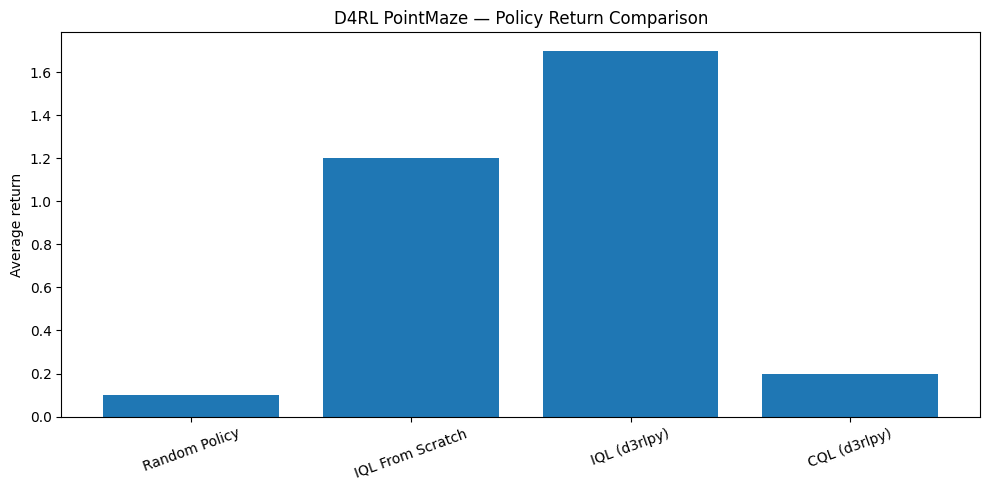

In [61]:
# ============================================================
# Plot Average Evaluation Return
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(
    results["Method"],
    results["Average Return"],
)
plt.ylabel("Average return")
plt.title("D4RL PointMaze — Policy Return Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 67. Plot Average Final Goal Distance

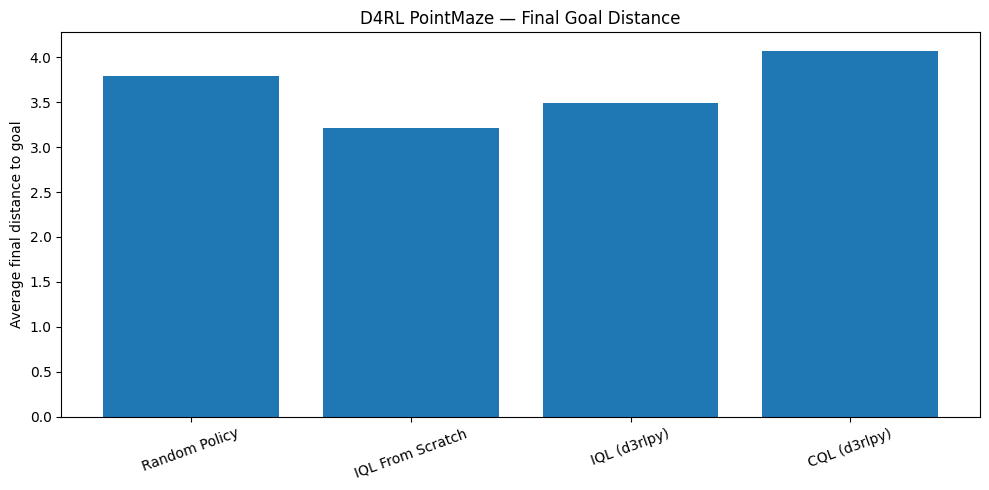

In [62]:
# ============================================================
# Plot Final Goal Distance
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(
    results["Method"],
    results["Average Final Goal Distance"],
)
plt.ylabel("Average final distance to goal")
plt.title("D4RL PointMaze — Final Goal Distance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Part XIII — Interpretation and Limitations

## 68. How to Interpret the Results

A stronger policy should generally show:

- higher average sparse return
- more rewarding steps
- smaller final distance to the goal

One run is not sufficient to claim universal superiority. Offline RL depends strongly on dataset coverage, random seed, hyperparameters, training budget, and evaluation protocol.

## 69. D4RL/Minari Dataset Lessons

The modern workflow is:

```text
D4RL benchmark identity
        ↓
Minari episode storage
        ↓
Gymnasium goal-conditioned observations
        ↓
Explicit flattening
        ↓
(s, a, r, s') arrays
        ↓
Offline-RL training
```

The key distinction is:

- **D4RL** = benchmark family and dataset lineage
- **Minari** = maintained offline dataset interface
- **Gymnasium-Robotics** = maintained PointMaze environment

## 70. Why `env.get_dataset()` Is Not Used

`env.get_dataset()` belonged to the legacy D4RL API. The recovered Gymnasium `TimeLimit` environment is a normal modern environment and does not expose that method.

The offline data come from the Minari `dataset` object.

## 71. Why `d4rl.qlearning_dataset()` Is Not Used

The legacy helper is unnecessary. Minari stores complete episodes with \(T+1\) observations for \(T\) actions, so the notebook can construct:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1})
$$

directly and transparently.

## 72. Limitations of the Manual IQL Implementation

The hand-written implementation is educational and portfolio-oriented. It is not claimed to reproduce every implementation detail from the original IQL paper.

A stronger research benchmark should add:

- multiple random seeds
- longer training
- systematic hyperparameter search
- checkpoint selection
- confidence intervals
- more detailed success metrics

# Part XIV — Strong Portfolio Extensions

## 73. Dataset-Quality Experiment

Repeat the workflow on other available D4RL PointMaze variants and compare how maze size, goal diversity, and dataset coverage influence offline learning.

## 74. Algorithm Comparison Extension

Possible additional methods:

- TD3+BC
- BCQ
- AWAC
- Behavior Cloning

This provides a wider view of offline-RL design choices.

## 75. Hyperparameter Sensitivity

For IQL, vary:

```text
expectile
advantage temperature
training steps
```

For CQL, vary:

```text
conservative weight
training steps
```

Report mean and standard deviation across repeated seeds.

# 76. Final Portfolio Takeaway

This repository demonstrates a complete modern D4RL offline-RL workflow:

```text
D4RL PointMaze Medium
        ↓
Minari dataset inspection
        ↓
Observation/action understanding
        ↓
Episode structure
        ↓
Explicit transition construction
        ↓
Dataset validation and statistics
        ↓
IQL from scratch
        ↓
IQL with d3rlpy
        ↓
CQL with d3rlpy
        ↓
Common evaluation
        ↓
Comparison and limitations
```

The central lesson is that offline RL learns a new policy from a fixed collection of logged experience without collecting new training transitions from the environment.